# Wav2Vec2 (Audio Transformer) — Fine-Tuning Baseline

This notebook fine-tunes a pre-trained `wav2vec2-base` model for 3-class language identification (English, Malay, Chinese) using your temporally split audio segments. We freeze the encoder and train only the classification head for a fast, stable baseline.

In [1]:
# Setup and Dependencies
import subprocess, sys

packages = [
    'torch', 'librosa', 'numpy', 'pandas', 'matplotlib',
    'transformers', 'ipywidgets', 'scikit-learn'
]
print('Checking dependencies...')
for pkg in packages:
    try:
        __import__(pkg)
        print(f'✅ {pkg}')
    except ImportError:
        print(f'📦 Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

Checking dependencies...
✅ torch
✅ librosa
✅ numpy
✅ pandas
✅ matplotlib
✅ transformers
✅ ipywidgets
📦 Installing scikit-learn...


In [2]:
# GPU Check
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | CUDA: {torch.version.cuda}")
else:
    print('⚠️ GPU not available — wav2vec2 training will be slow')

globals()['device'] = device

Using device: cuda
GPU: NVIDIA GeForce GTX 1650 | CUDA: 11.8


In [ ]:
# Config and Paths
import os
SPLIT_DIR = os.path.join(os.getcwd(), 'Dataset', 'audio_split')
SAMPLE_RATE = 16000
SEGMENT_LENGTH = 10  # 10s segments for wav2vec2
LANG_MAP = {'en': 0, 'ms': 1, 'zh': 2}
LANG_NAMES = ['English', 'Malay', 'Chinese']
BATCH_SIZE = 8  # memory-friendly for GPU
NUM_EPOCHS = 5  # short baseline run
LEARNING_RATE = 1e-3

print('Split dir:', SPLIT_DIR)
print('Segment length:', SEGMENT_LENGTH)

In [4]:
# Load split files
from typing import List, Tuple

def load_split_files(split_name: str) -> Tuple[List[str], List[int]]:
    audio_files, labels = [], []
    split_path = os.path.join(SPLIT_DIR, split_name)
    print(f"\nLoading {split_name} split:")
    for lang_name, lang_id in LANG_MAP.items():
        file_path = os.path.join(split_path, f'{lang_name}_{split_name}.wav')
        if os.path.exists(file_path):
            audio_files.append(file_path)
            labels.append(lang_id)
            print(f"  ✅ {lang_name}: {os.path.basename(file_path)}")
        else:
            print(f"  ❌ {lang_name}: missing {file_path}")
    return audio_files, labels

train_files, train_labels = load_split_files('train')
val_files, val_labels = load_split_files('val')
test_files, test_labels = load_split_files('test')


Loading train split:
  ✅ en: en_train.wav
  ✅ ms: ms_train.wav
  ✅ zh: zh_train.wav

Loading val split:
  ✅ en: en_val.wav
  ✅ ms: ms_val.wav
  ✅ zh: zh_val.wav

Loading test split:
  ✅ en: en_test.wav
  ✅ ms: ms_test.wav
  ✅ zh: zh_test.wav


In [5]:
# Dataset for Wav2Vec2
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader

class Wav2Vec2Dataset(Dataset):
    def __init__(self, audio_files, labels, segment_length=10, sr=16000):
        self.audio_files = audio_files
        self.labels = labels
        self.segment_length = segment_length
        self.sr = sr
        self.segment_samples = segment_length * sr
        # Precompute segment indices (file_idx, seg_idx)
        self.segments = []
        for idx, file_path in enumerate(audio_files):
            try:
                duration = librosa.get_duration(path=file_path)
                num_segments = int(duration // segment_length)
                for seg_idx in range(num_segments):
                    self.segments.append((idx, seg_idx))
            except Exception as e:
                print(f"⚠️  Error reading {file_path}: {e}")
        print(f"Dataset: {len(self.audio_files)} files → {len(self.segments)} segments ({segment_length}s)")

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        file_idx, seg_idx = self.segments[idx]
        file_path = self.audio_files[file_idx]
        label = self.labels[file_idx]
        offset = seg_idx * self.segment_length
        y, sr = librosa.load(file_path, sr=self.sr, offset=offset, duration=self.segment_length, mono=True)
        if len(y) < self.segment_samples:
            y = np.pad(y, (0, self.segment_samples - len(y)))
        return y.astype(np.float32), label

In [6]:
# Processor, Collate, and Model
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
import torch.nn.functional as F

processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base')
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    'facebook/wav2vec2-base',
    num_labels=3,
    problem_type='single_label_classification'
).to(device)

# Freeze encoder; train classification head only
for p in model.wav2vec2.parameters():
    p.requires_grad = False

print('Trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))

# Collate function: pad raw audio
import torch

def collate_fn(batch):
    # Pass numpy arrays directly; processor expects 1D arrays per sample
    waveforms = [x[0] for x in batch]
    labels = torch.tensor([x[1] for x in batch], dtype=torch.long)
    inputs = processor(waveforms, sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True)
    # Sanity check & fix odd batch shapes from some torch/transformers versions
    iv = inputs['input_values']
    if iv.ndim == 3 and iv.shape[0] == 1:
        inputs['input_values'] = iv.squeeze(0)
        if 'attention_mask' in inputs and inputs['attention_mask'].ndim == 3 and inputs['attention_mask'].shape[0] == 1:
            inputs['attention_mask'] = inputs['attention_mask'].squeeze(0)
    assert inputs['input_values'].ndim == 2, f"Bad input_values shape: {tuple(inputs['input_values'].shape)}"
    return inputs, labels

# Build datasets and loaders
train_ds = Wav2Vec2Dataset(train_files, train_labels, SEGMENT_LENGTH, SAMPLE_RATE)
val_ds = Wav2Vec2Dataset(val_files, val_labels, SEGMENT_LENGTH, SAMPLE_RATE)
test_ds = Wav2Vec2Dataset(test_files, test_labels, SEGMENT_LENGTH, SAMPLE_RATE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print('✅ Dataloaders ready')

c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\fypenv\lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 197635
Dataset: 3 files → 453 segments (10s)
Dataset: 3 files → 96 segments (10s)
Dataset: 3 files → 96 segments (10s)
✅ Dataloaders ready


In [7]:
# Training Loop (Classification Head Only)
import torch.optim as optim
import numpy as np
from tqdm.notebook import tqdm

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

best_val_acc = 0.0
print('🚀 Starting training...')
for epoch in tqdm(range(NUM_EPOCHS), desc='Epochs', unit='epoch'):
    # Train
    model.train()
    train_correct, train_total = 0, 0
    debug_printed = False
    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1} Train', leave=False):
        # Debug input shape once
        if not debug_printed:
            iv = inputs['input_values']
            print('input_values shape:', tuple(iv.shape))
            debug_printed = True
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(**inputs)
        loss = F.cross_entropy(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        preds = outputs.logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    train_acc = 100.0 * train_correct / train_total

    # Validate
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1} Val', leave=False):
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)
            outputs = model(**inputs)
            preds = outputs.logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = 100.0 * val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained('best_wav2vec2_model')
        print(f'Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}% 🌟')
    else:
        print(f'Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%')

print(f'✅ Training complete. Best Val Acc: {best_val_acc:.2f}%')

🚀 Starting training...


Epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1 Train:   0%|          | 0/57 [00:00<?, ?it/s]

input_values shape: (8, 160000)


Epoch 1 Val:   0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch 4: Train 90.29% | Val 78.12%


Epoch 5 Train:   0%|          | 0/57 [00:00<?, ?it/s]

input_values shape: (8, 160000)


Epoch 5 Val:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 5: Train 93.16% | Val 85.42% 🌟
✅ Training complete. Best Val Acc: 85.42%


Testing:   0%|          | 0/12 [00:00<?, ?batch/s]

🎯 Test Accuracy: 87.50%
              precision    recall  f1-score   support

     English     0.8000    1.0000    0.8889        32
       Malay     0.9286    0.8125    0.8667        32
     Chinese     0.9286    0.8125    0.8667        32

    accuracy                         0.8750        96
   macro avg     0.8857    0.8750    0.8741        96
weighted avg     0.8857    0.8750    0.8741        96



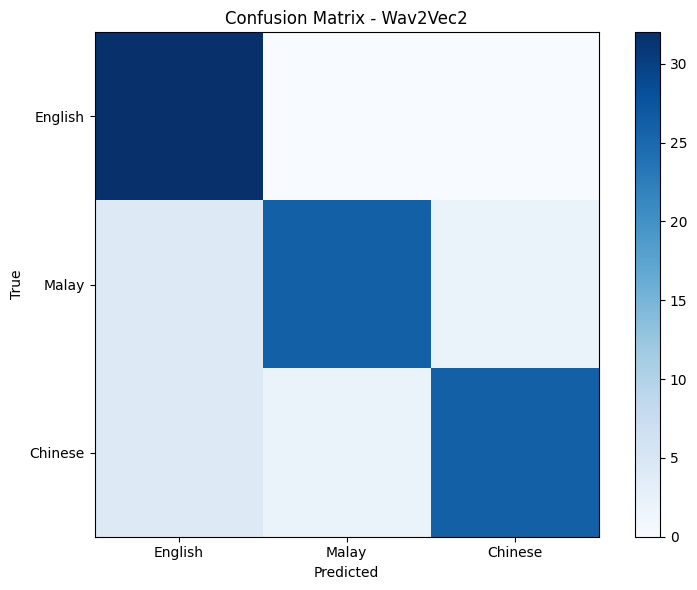

💾 Saved: wav2vec2_test_predictions.csv, wav2vec2_metrics_summary.json


In [8]:
# Evaluation and Export
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing', unit='batch'):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        preds = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = 100.0 * (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
print(f"🎯 Test Accuracy: {acc:.2f}%")
print(classification_report(all_labels, all_preds, target_names=LANG_NAMES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(3), yticks=np.arange(3),
       xticklabels=LANG_NAMES, yticklabels=LANG_NAMES,
       title='Confusion Matrix - Wav2Vec2', ylabel='True', xlabel='Predicted')
plt.tight_layout()
plt.show()

# Export metrics
import pandas as pd, json
results_df = pd.DataFrame({
    'true_label': [LANG_NAMES[l] for l in all_labels],
    'predicted_label': [LANG_NAMES[p] for p in all_preds],
    'true_id': all_labels,
    'predicted_id': all_preds,
    'prob_en': [p[0] for p in all_probs],
    'prob_ms': [p[1] for p in all_probs],
    'prob_zh': [p[2] for p in all_probs],
})
results_df.to_csv('wav2vec2_test_predictions.csv', index=False)

metrics_summary = {
    'model': 'wav2vec2-base (head only)',
    'test_accuracy': float(acc),
    'confusion_matrix': cm.tolist(),
}
with open('wav2vec2_metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print('💾 Saved: wav2vec2_test_predictions.csv, wav2vec2_metrics_summary.json')

In [9]:

# Baseline Summary: Wav2Vec2 Unimodal Performance
print("="*60)
print("📊 WAV2VEC2 BASELINE (AUDIO ONLY)")
print("="*60)
print(f"✅ Model: facebook/wav2vec2-base (frozen encoder + head)")
print(f"✅ Test Accuracy: {acc:.2f}%")
print(f"✅ Checkpoint saved: best_wav2vec2_model/")
print(f"✅ Metrics exported: wav2vec2_metrics_summary.json")
print("="*60)
print("\n📝 Per-Language Accuracy:")
for i, lang in enumerate(LANG_NAMES):
    lang_mask = np.array(all_labels) == i
    if lang_mask.sum() > 0:
        lang_acc = 100.0 * (np.array(all_preds)[lang_mask] == np.array(all_labels)[lang_mask]).sum() / lang_mask.sum()
        print(f"   {lang}: {lang_acc:.2f}%")
print("\n💡 Next: Load this checkpoint in Wav+Distilbert.ipynb for multimodal fusion")


📊 WAV2VEC2 BASELINE (AUDIO ONLY)
✅ Model: facebook/wav2vec2-base (frozen encoder + head)
✅ Test Accuracy: 87.50%
✅ Checkpoint saved: best_wav2vec2_model/
✅ Metrics exported: wav2vec2_metrics_summary.json

📝 Per-Language Accuracy:
   English: 100.00%
   Malay: 81.25%
   Chinese: 81.25%

💡 Next: Load this checkpoint in Wav+Distilbert.ipynb for multimodal fusion
